# Atividade 2

**Membros:**

*   Giulia Monteiro Garrido (RA: 24010281)
*   Thomaz Dacorso (RA: 24012310)
*   Victor França (RA: 24010801)
*   Vitor Furuta (RA: 24008775)

### 1. Gerenciamento e Quarentena

In [1]:
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
from datetime import datetime

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aliiihussain/amazon-sales-dataset")

print("Path to dataset files:", path)

/home/giugarrido/Área de trabalho/Faculdade/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/giugarrido/.cache/kagglehub/datasets/aliiihussain/amazon-sales-dataset/versions/1


In [3]:
name_files = os.listdir(path)
new_path = path+"/"+name_files[0]
csv_file = open(new_path)
df = pd.read_csv(csv_file)

In [4]:
VISTAS_DIR        = "vistas_lote"
GERENCIAMENTO_DIR = "gerenciamento"

os.makedirs(VISTAS_DIR, exist_ok=True)
os.makedirs(GERENCIAMENTO_DIR, exist_ok=True)

QUARENTENA_LINHAS_PATH = os.path.join(GERENCIAMENTO_DIR, "quarentena_linhas_brutas.csv")
QUARENTENA_RESUMO_PATH = os.path.join(GERENCIAMENTO_DIR, "quarentena_linhas_por_arquivo.csv")

In [5]:
def validar_linha(row):

    if row.isnull().any():
        return "campo_nulo"
    
    if row["price"] <= 0 or row["total_revenue"] <= 0 or row["discounted_price"] <= 0:
        return "valor_financeiro_invalido"
    
    if row["quantity_sold"] < 1:
        return "quantidade_invalida"
    
    if not (1.0 <= row["rating"] <= 5.0):
        return "rating_fora_do_intervalo"
    
    if not (0 <= row["discount_percent"] <= 100):
        return "desconto_invalido"
    
    return None

In [6]:
motivos = df.apply(validar_linha, axis=1)
mask_validas = motivos.isna()

df_valido = df[mask_validas].copy()
df_quarentena = df[~mask_validas].copy()
df_quarentena["motivo_quarentena"] = motivos[~mask_validas]
df_quarentena["arquivo_origem"] = os.path.basename(new_path)

In [7]:
df_quarentena.to_csv(QUARENTENA_LINHAS_PATH, index=False)

resumo_quarentena = pd.DataFrame([{
    "arquivo": os.path.basename(new_path),
    "linhas_totais": len(df),
    "linhas_validas": len(df_valido),
    "linhas_quarentena": len(df_quarentena),
    "timestamp": datetime.now().isoformat()
}])

resumo_quarentena.to_csv(QUARENTENA_RESUMO_PATH, index=False)


### 2. Particionamento dos Dados

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [9]:
df['order_date'] = pd.to_datetime(df['order_date'])


In [10]:
df.groupby(df['order_date'].dt.year).size()

order_date
2022    24926
2023    25074
dtype: int64

In [11]:
df.groupby(df['order_date'].dt.to_period('M')).size().reset_index(name='count').rename(columns={'order_date': 'year_month'})

,year_month,count
0,2022-01,2151
1,2022-02,1899
2,2022-03,2155
3,2022-04,2089
4,2022-05,2073
5,2022-06,2044
6,2022-07,2093
7,2022-08,2189
8,2022-09,2100
9,2022-10,2060


In [12]:
df_2022=df[df["order_date"].dt.year == 2022]

In [13]:
df_2022

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72
6,7,2022-01-21,4068,Books,15.78,0,5,Asia,UPI,1.6,415,15.78,78.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49992,49993,2022-12-30,4078,Fashion,33.20,0,5,Middle East,Cash on Delivery,2.5,357,33.20,166.00
49993,49994,2022-09-04,3615,Sports,306.98,15,2,North America,Wallet,4.8,438,260.93,521.86
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05


In [14]:
years = []
for i in df["order_date"]:
    if i.year not in years:
        years.append(i.year)

years.sort()
print(years)

[2022, 2023]


In [15]:
months = []
for i in df["order_date"]:
    if i.month not in months:
        months.append(i.month)
months.sort()
print(months)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [16]:
os.makedirs("data", exist_ok=True)

for year in years:
    folder_path_year = f"data/{year}"
    os.makedirs(folder_path_year, exist_ok=True)
    for month in months:
        folder_path_month = f"{folder_path_year}/{month}"
        os.makedirs(folder_path_month, exist_ok=True)
        df_month = df[(df["order_date"].dt.year == year) & (df["order_date"].dt.month == month)]
        with open(f"{folder_path_month}/data.csv", "w") as f:
            (df_month.to_csv(f, index=False))

### 3. Criação das Vistas de Lote

In [18]:
df_valido["order_date"] = pd.to_datetime(df_valido["order_date"])

def construir_vistas_de_lote(df):

    os.makedirs(VISTAS_DIR, exist_ok=True)

    vista_receita_mes = (
        df.groupby(df["order_date"].dt.to_period("M"))["total_revenue"]
        .sum()
        .reset_index()
        .rename(columns={"order_date": "ano_mes", "total_revenue": "receita_total"})
    )

    vista_receita_mes["ano_mes"] = vista_receita_mes["ano_mes"].astype(str)
    vista_receita_mes.to_csv(os.path.join(VISTAS_DIR, "receita_por_mes.csv"), index=False)

    vista_categoria = (
        df.groupby("product_category")
        .agg(
            total_vendas =("order_id", "count"),
            receita_total=("total_revenue", "sum"),
            preco_medio  =("price", "mean"),
            rating_medio =("rating", "mean"),
        ).reset_index().round(2)
    )

    vista_categoria.to_csv(os.path.join(VISTAS_DIR, "vendas_por_categoria.csv"), index=False)

    vista_regiao = (
        df.groupby("customer_region")
        .agg(
            total_vendas =("order_id", "count"),
            receita_total=("total_revenue", "sum"),
            receita_media =("total_revenue", "mean"),
        ).reset_index().round(2)
    )

    vista_regiao.to_csv(os.path.join(VISTAS_DIR, "vendas_por_regiao.csv"), index=False)

    vista_pagamento = (
        df.groupby("payment_method")
        .agg(
            total_vendas =("order_id", "count"),
            receita_total=("total_revenue", "sum"),
        ).reset_index().round(2)
    )

    vista_pagamento.to_csv(os.path.join(VISTAS_DIR, "vendas_por_pagamento.csv"), index=False)

    vista_desconto = (
        df.groupby("product_category")
        .agg(
            desconto_medio =("discount_percent", "mean"),
            preco_desc_medio =("discounted_price", "mean"),
            qtd_media =("quantity_sold", "mean"),
        ).reset_index().round(2)
    )

    vista_desconto.to_csv(os.path.join(VISTAS_DIR, "desconto_por_categoria.csv"), index=False)

    vista_dia = (
        df.groupby(df["order_date"].dt.date)
        .agg(
            total_vendas =("order_id", "count"),
            receita_total=("total_revenue", "sum"),
        ).reset_index().rename(columns={"order_date": "data"}).round(2)
    )

    vista_dia.to_csv(os.path.join(VISTAS_DIR, "vendas_por_dia.csv"), index=False)

    print(f"6 vistas de lote construídas em '{VISTAS_DIR}/'")
    return {
        "receita_por_mes": vista_receita_mes,
        "vendas_por_categoria": vista_categoria,
        "vendas_por_regiao": vista_regiao,
        "vendas_por_pagamento": vista_pagamento,
        "desconto_por_categoria": vista_desconto,
        "vendas_por_dia": vista_dia,
    }

vistas = construir_vistas_de_lote(df_valido)

6 vistas de lote construídas em 'vistas_lote/'


In [19]:
v_receita = pd.read_csv(os.path.join(VISTAS_DIR, "receita_por_mes.csv"))
v_categoria = pd.read_csv(os.path.join(VISTAS_DIR, "vendas_por_categoria.csv"))
v_regiao = pd.read_csv(os.path.join(VISTAS_DIR, "vendas_por_regiao.csv"))
v_pagamento = pd.read_csv(os.path.join(VISTAS_DIR, "vendas_por_pagamento.csv"))
v_desconto = pd.read_csv(os.path.join(VISTAS_DIR, "desconto_por_categoria.csv"))
v_dia = pd.read_csv(os.path.join(VISTAS_DIR, "vendas_por_dia.csv"))

### 4. Consultas

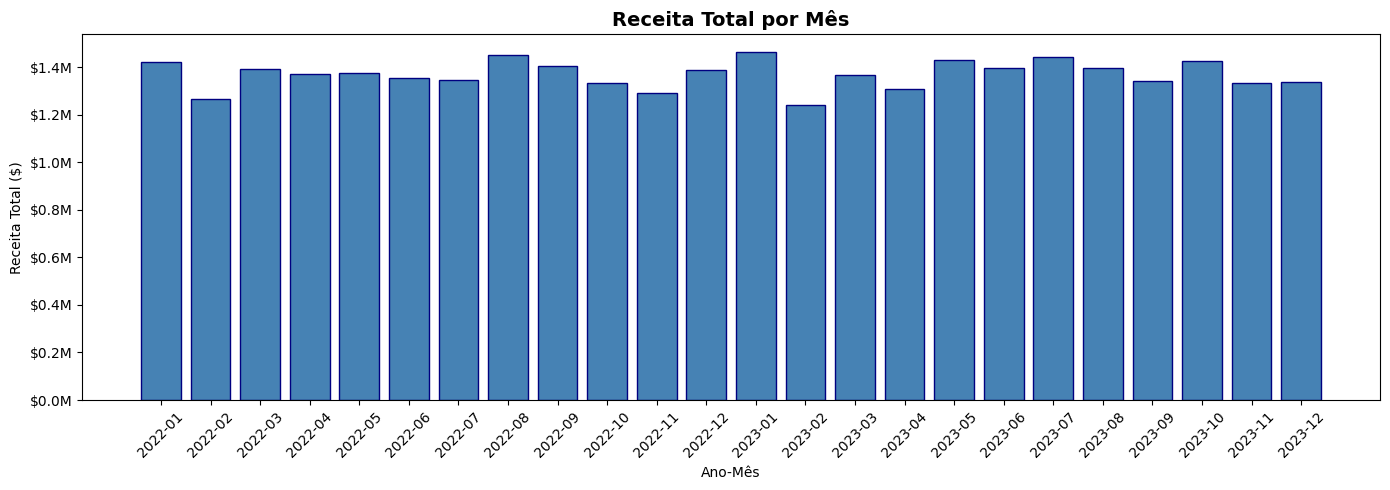

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(v_receita['ano_mes'], v_receita['receita_total'], color='steelblue', edgecolor='navy')
ax.set_title('Receita Total por Mês', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Receita Total ($)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

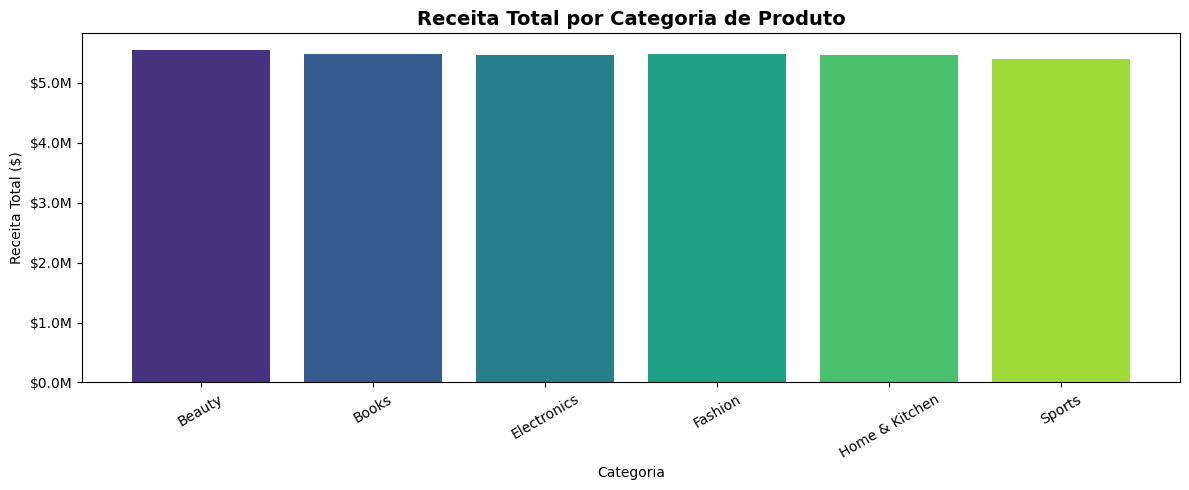

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(v_categoria['product_category'], v_categoria['receita_total'], color=sns.color_palette('viridis', len(v_categoria)))
ax.set_title('Receita Total por Categoria de Produto', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoria')
ax.set_ylabel('Receita Total ($)')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

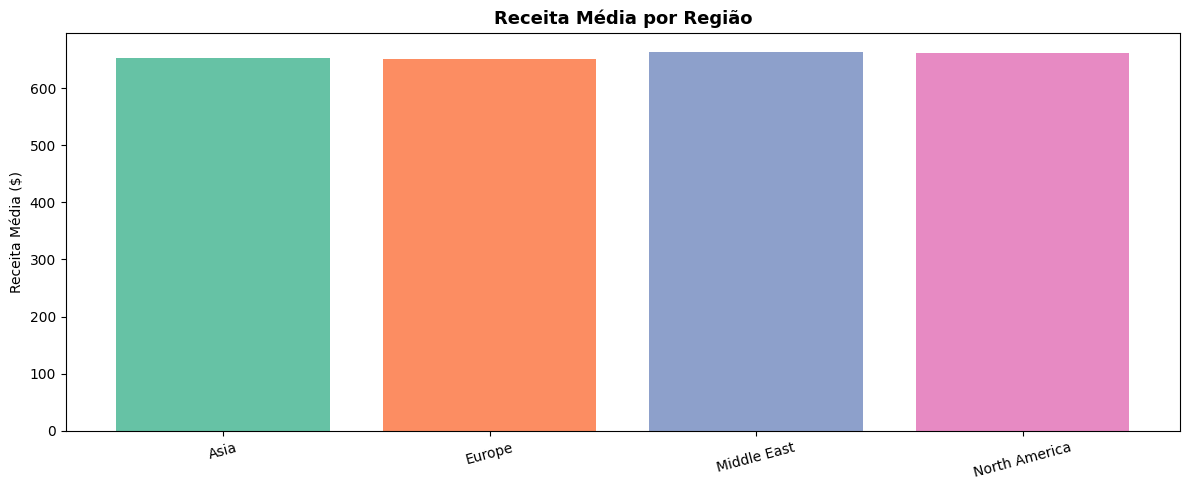

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(v_regiao['customer_region'], v_regiao['receita_media'], color=sns.color_palette('Set2', len(v_regiao)))
ax.set_title('Receita Média por Região', fontsize=13, fontweight='bold')
ax.set_ylabel('Receita Média ($)')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

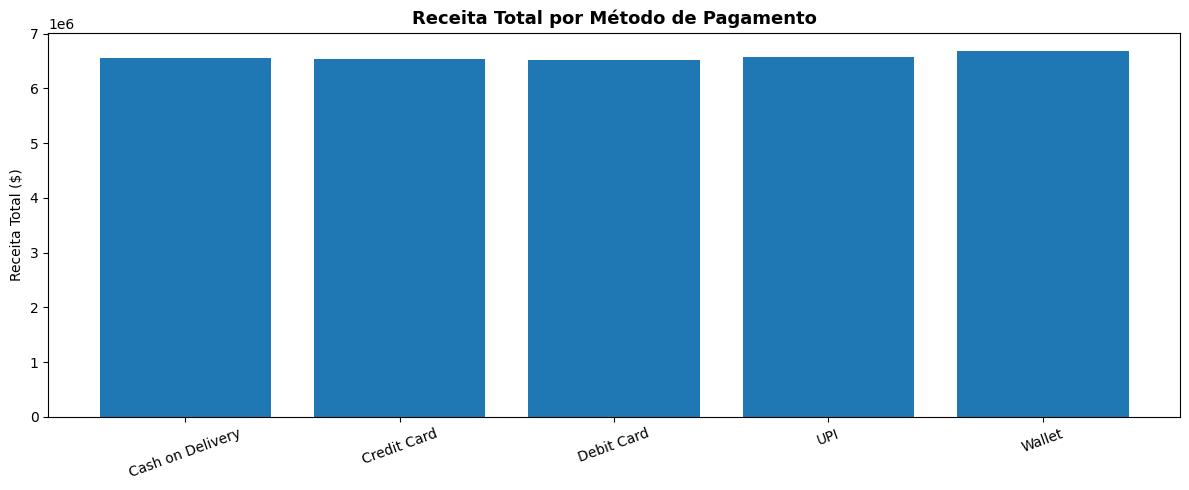

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(v_pagamento['payment_method'], v_pagamento['receita_total'])
ax.set_title('Receita Total por Método de Pagamento', fontsize=13, fontweight='bold')
ax.set_ylabel('Receita Total ($)')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()